# Hoja de trabajo 2: Transformers y mecanismos de atención

**Curso:** CC3092 Deep Learning y Sistemas Inteligentes  
**Objetivo:** comprender la transición desde modelos recurrentes hacia Transformers y analizar de forma empírica los patrones de atención de BERT y GPT-2.

Este notebook integra investigación, derivaciones, implementación, visualizaciones, resultados, discusión y referencias. Las afirmaciones se redactan con palabras propias a partir de artículos originales y documentación oficial.

## 1. Configuración reproducible

La semilla fija permite repetir los ejemplos numéricos. Los modelos se cargan con atención explícita para obtener los pesos por capa y cabeza. Las figuras se guardan en la carpeta `figuras`.

In [1]:
from pathlib import Path
from time import perf_counter
import math
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", context="notebook")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


## 2. De las RNN a la atención

### El cuello de botella de seq2seq

Un encoder recurrente clásico comprime toda la oración fuente en un único estado final. Ese vector fijo debe conservar identidad, orden y relaciones entre todos los tokens. Cuando la secuencia crece, la información temprana atraviesa muchos pasos recurrentes y compite por una capacidad limitada. Esto dificulta preservar detalles y propagar gradientes.

La atención de Bahdanau conserva todos los estados del encoder. En cada paso, el decoder calcula una puntuación de alineamiento entre su estado y cada estado fuente. Una softmax convierte esas puntuaciones en pesos y produce un contexto ponderado. El decoder obtiene así un acceso directo y diferenciable a la parte pertinente de la entrada.

### Atención aditiva y multiplicativa

La atención aditiva concatena o combina consulta y clave mediante proyecciones aprendidas, una no linealidad tanh y un vector de puntuación. La atención multiplicativa calcula un producto punto, a veces después de una proyección. La variante aditiva puede ser flexible con dimensiones pequeñas. La variante de producto punto aprovecha multiplicaciones matriciales densas y suele ser más rápida en GPU y TPU por su alto nivel de paralelismo.

### Consulta, llave y valor

La analogía útil es un diccionario suave. La consulta expresa qué información se busca. Cada llave describe cuándo resulta pertinente una entrada. La similitud entre consulta y llaves produce pesos continuos. La suma ponderada de los valores recupera una mezcla de información en vez de elegir una sola entrada.

En self-attention, Q, K y V son proyecciones lineales de la misma secuencia. En cross-attention, Q procede del estado del decoder, mientras K y V proceden de la salida del encoder.

### Limitaciones recurrentes que evita el Transformer

Una RNN procesa tokens en orden y no puede paralelizar todos los pasos durante entrenamiento. Además, la ruta entre tokens distantes crece con la longitud y agrava la pérdida o explosión de gradientes. En self-attention, cada token se conecta directamente con todos los demás en una sola capa. Esto permite paralelismo por posición y rutas cortas para dependencias largas. El costo es una matriz de atención cuadrática en la longitud.

## 3. Arquitectura Transformer

### Producto punto escalado

La atención se define como

$$\operatorname{softmax}\left[\frac{QK^T}{\sqrt{d_k}}\right]V$$

Si los componentes de q y k son independientes, con media cero y varianza uno, cada producto tiene varianza uno. La suma de $d_k$ productos tiene varianza $d_k$. Dividir por $\sqrt{d_k}$ devuelve la varianza a una escala cercana a uno. Sin ese factor, los logits crecen con la dimensión, la softmax se satura y sus gradientes se aproximan a cero.

### Múltiples cabezas

Cada cabeza aprende proyecciones distintas y puede representar relaciones complementarias, como cercanía, puntuación, concordancia o referencia. Con $h$ cabezas de dimensión $d_{model}/h$, el costo dominante de las proyecciones se mantiene aproximadamente igual al de una sola cabeza de dimensión completa. La arquitectura estándar conserva cerca de $4d_{model}^2$ parámetros entre Q, K, V y la proyección de salida.

### Información posicional

Sin información adicional, self-attention es equivariante ante permutaciones. Reordenar tokens reordena las salidas pero no aporta una noción propia de antes y después.

La codificación sinusoidal asigna senos y cosenos de distintas frecuencias a cada posición. No agrega parámetros y permite extrapolar de forma limitada a longitudes nuevas. Los embeddings aprendidos pueden adaptarse al corpus, pero quedan ligados al máximo entrenado. RoPE rota pares de componentes de Q y K según su posición y hace que el producto punto dependa de desplazamientos relativos.

### Bloque completo

La conexión residual preserva una ruta directa para información y gradientes. LayerNorm estabiliza escalas entre características. La red feed-forward aplica dos transformaciones lineales y una no lineal a cada posición de forma independiente.

Post-LN normaliza después de sumar el residual, como en el artículo original. Pre-LN normaliza antes de cada subcapa y deja una ruta residual más limpia. Pre-LN suele optimizarse con mayor estabilidad en redes profundas, aunque Post-LN puede alcanzar representaciones finales distintas con una calibración cuidadosa.

### Complejidad y alternativas

La atención estándar requiere tiempo y memoria de orden $n^2$ para formar y usar la matriz entre posiciones.

- FlashAttention calcula atención exacta por bloques y reduce movimientos entre memorias. No sacrifica exactitud matemática, pero exige núcleos y hardware compatibles.
- La atención por ventanas restringe cada token a vecinos. Su costo pasa a ser cercano a lineal para ventana fija, a cambio de perder conexiones globales directas salvo que se añadan tokens globales.
- La atención lineal usa mapas de características y cambia el orden de los productos. Reduce el costo respecto a la longitud, pero aproxima o sustituye la softmax y puede alterar calidad y estabilidad.

## 4. Atención en PyTorch y Hugging Face

### PyTorch

`F.scaled_dot_product_attention` ejecuta el producto punto escalado. `attn_mask` restringe pares entre consultas y claves. `dropout_p` controla regularización y debe ser cero durante evaluación. `is_causal` crea una restricción autoregresiva. `scale` permite sustituir el factor de escala predeterminado.

`nn.MultiheadAttention` implementa proyecciones para varias cabezas. `embed_dim` fija la dimensión del modelo, `num_heads` la cantidad de cabezas, `batch_first` permite el orden lote, secuencia y características, y `kdim` junto con `vdim` permiten claves y valores con dimensiones distintas. En la llamada, `key_padding_mask` oculta padding, `attn_mask` define restricciones entre posiciones, `need_weights` solicita pesos y `average_attn_weights` decide si se promedian las cabezas.

`nn.TransformerEncoderLayer` reúne self-attention, feed-forward, residuales, normalización y dropout. Sus parámetros principales son `d_model`, `nhead`, `dim_feedforward`, `dropout` y `norm_first`. El último selecciona Pre-LN cuando es verdadero. `nn.Transformer.generate_square_subsequent_mask` produce la máscara causal triangular para impedir acceso al futuro.

### Hugging Face

`output_attentions=True` solicita los pesos posteriores a la softmax. El resultado contiene una tupla con un tensor por capa. Para self-attention, cada tensor presenta ejes de lote, cabezas, consultas y claves. Con una secuencia de longitud $n$, la forma es lote por cabezas por $n$ por $n$.

## 5. Verificación manual y práctica básica

Para una consulta, se calculan productos con cada llave, se escalan, se normalizan con softmax y se combinan los valores. La siguiente celda muestra cada resultado y lo compara con la función optimizada de PyTorch.

In [2]:
Q = torch.tensor([[[[1.0, 0.0]]]])
K = torch.tensor([[[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]])
V = torch.tensor([[[[1.0, 0.0], [0.0, 2.0], [3.0, 1.0]]]])

scores = Q @ K.transpose(-2, -1) / math.sqrt(K.size(-1))
weights = scores.softmax(dim=-1)
manual = weights @ V
pytorch = F.scaled_dot_product_attention(Q, K, V, dropout_p=0.0)

print("Puntuaciones:", scores)
print("Pesos:", weights)
print("Salida manual:", manual)
print("Salida PyTorch:", pytorch)
torch.testing.assert_close(manual, pytorch)

Puntuaciones: tensor([[[[0.7071, 0.0000, 0.7071]]]])
Pesos: tensor([[[[0.4011, 0.1978, 0.4011]]]])
Salida manual: tensor([[[[1.6044, 0.7967]]]])
Salida PyTorch: tensor([[[[1.6044, 0.7967]]]])


In [3]:
embed_dim = 8
heads = 2
x = torch.randn(2, 5, embed_dim)
mha = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
out, attn = mha(x, x, x, need_weights=True, average_attn_weights=False)
layer = nn.TransformerEncoderLayer(
    d_model=embed_dim,
    nhead=heads,
    dim_feedforward=32,
    dropout=0.0,
    batch_first=True,
    norm_first=True,
)
causal_mask = nn.Transformer.generate_square_subsequent_mask(x.size(1))
encoded = layer(x, src_mask=causal_mask)
print("Salida MHA:", tuple(out.shape))
print("Pesos por cabeza:", tuple(attn.shape))
print("Salida del encoder:", tuple(encoded.shape))
print(causal_mask)

Salida MHA: (2, 5, 8)
Pesos por cabeza: (2, 2, 5, 5)
Salida del encoder: (2, 5, 8)
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


### Escalamiento teórico y costo medido

El número de elementos de la matriz crece como $n^2$. La medición siguiente usa tensores pequeños y repeticiones breves para observar la tendencia sin convertirla en una prueba exhaustiva de rendimiento.

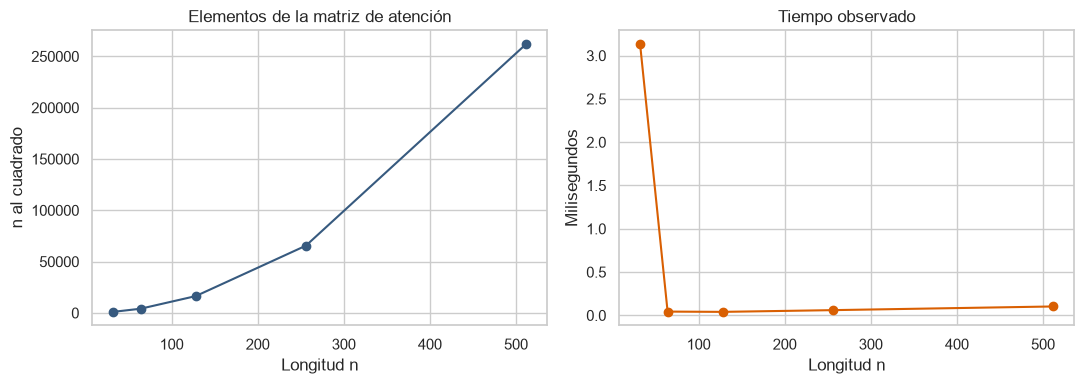

In [4]:
lengths = np.array([32, 64, 128, 256, 512])
theoretical = lengths ** 2
times = []
for n in lengths:
    q = torch.randn(1, 2, int(n), 32, device=DEVICE)
    k = torch.randn_like(q)
    v = torch.randn_like(q)
    start = perf_counter()
    for _ in range(3):
        _ = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    times.append((perf_counter() - start) / 3 * 1000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lengths, theoretical, marker="o", color="#375a7f")
axes[0].set_title("Elementos de la matriz de atención")
axes[0].set_xlabel("Longitud n")
axes[0].set_ylabel("n al cuadrado")
axes[1].plot(lengths, times, marker="o", color="#d95f02")
axes[1].set_title("Tiempo observado")
axes[1].set_xlabel("Longitud n")
axes[1].set_ylabel("Milisegundos")
fig.tight_layout()
fig.savefig(FIG_DIR / "escalamiento_atencion.png", dpi=180, bbox_inches="tight")
plt.show()